# 07_negocio — Escenario de valor para EPS e IPS

Este notebook construye el componente de negocio del proyecto: traduce la matriz analítica de RNA-Seq y los resultados del modelado en un escenario operativo comprensible para EPS e IPS.

El objetivo es estimar, de forma reproducible, cómo una solución analítica basada en expresión génica y aprendizaje automático podría apoyar la clasificación de tipos de cáncer, priorizar rutas diagnósticas, reducir tiempos estimados de atención y disminuir reprocesos operativos.

Esta versión incorpora una simulación diferenciada por EPS, de modo que las visualizaciones no queden homogéneas: algunas EPS concentran mayor oportunidad de mejora, otras muestran menor costo final y otras presentan mayor ahorro promedio estimado.

> **Nota metodológica:** las variables de EPS, IPS, costos y tiempos se construyen como un escenario simulado para comunicación analítica y evaluación de valor. No representan datos reales de aseguramiento, facturación o atención clínica individual.


## 1. Configuración del entorno

Se definen librerías, rutas de trabajo y carpetas de salida. El notebook usa la capa `refined` porque parte de datos ya preparados para modelado y genera salidas listas para visualización, reporte o prototipo.

In [91]:
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

# Rutas base del proyecto
BASE_PATH = Path("data_local")
REFINED_PATH = BASE_PATH / "refined"
TABLES_PATH = REFINED_PATH / "tables"
VIZ_PATH = REFINED_PATH / "visualizations" / "negocio_eps_ips"
APP_EXPORTS_PATH = REFINED_PATH / "app_exports" / "negocio_eps_ips"

# Entradas principales
MATRIZ_MODELADO_PATH = TABLES_PATH / "refined_ml_matriz_modelado_desde_feature_selection"
PREDICCIONES_TEST_PATH = TABLES_PATH / "refined_predicciones_test_mejor_modelo"

# Salidas de negocio
CONTEXTO_NEGOCIO_PATH = TABLES_PATH / "refined_contexto_negocio_eps_ips_cohorte"
RESUMEN_EJECUTIVO_PATH = TABLES_PATH / "refined_resumen_ejecutivo_eps_ips_cohorte"
RESUMEN_EPS_PATH = TABLES_PATH / "refined_resumen_por_eps_cohorte"
RESUMEN_CANCER_PATH = TABLES_PATH / "refined_resumen_por_tipo_cancer_cohorte"

for path in [TABLES_PATH, VIZ_PATH, APP_EXPORTS_PATH]:
    path.mkdir(parents=True, exist_ok=True)

print("Ruta refined:", REFINED_PATH.resolve())
print("Ruta tablas:", TABLES_PATH.resolve())
print("Ruta visualizaciones:", VIZ_PATH.resolve())
print("Ruta app_exports:", APP_EXPORTS_PATH.resolve())

Ruta refined: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined
Ruta tablas: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/tables
Ruta visualizaciones: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/negocio_eps_ips
Ruta app_exports: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/app_exports/negocio_eps_ips


## 2. Funciones auxiliares

Estas funciones estandarizan el guardado de tablas y el formato de valores monetarios. De esta forma, las salidas quedan ordenadas en Parquet y CSV, lo que facilita su uso posterior en dashboards, reportes o aplicaciones.

In [92]:
def guardar_tabla_refined(df: pd.DataFrame, ruta: Path, nombre_logico: str) -> None:
    """Guarda una tabla en formato Parquet y CSV, reemplazando versiones anteriores."""
    if ruta.exists():
        shutil.rmtree(ruta)
    ruta.mkdir(parents=True, exist_ok=True)
    df.to_parquet(ruta / "data.parquet", index=False)
    df.to_csv(ruta / "data.csv", index=False)
    print(f"Tabla guardada: {nombre_logico}")
    print(f"  - {ruta.resolve()}")
    print(f"  - dimensiones: {df.shape}")


def exportar_csv_app(df: pd.DataFrame, nombre_archivo: str) -> None:
    """Exporta una tabla en CSV para consumo de prototipos o dashboards."""
    salida = APP_EXPORTS_PATH / nombre_archivo
    df.to_csv(salida, index=False)
    print(f"Exportado para app: {salida.resolve()}")


def millones_cop(valor):
    """Convierte pesos colombianos a millones de COP."""
    return valor / 1_000_000


def miles_cop(valor):
    """Convierte pesos colombianos a miles de COP."""
    return valor / 1_000

## 3. Validación de entradas disponibles

Antes de construir la capa de negocio se verifica que existan las tablas necesarias. La entrada principal es la matriz completa de modelado, porque permite representar toda la cohorte analítica y no solo el subconjunto de prueba.

In [93]:
entradas = {
    "Matriz completa de modelado": MATRIZ_MODELADO_PATH,
    "Predicciones del mejor modelo en test": PREDICCIONES_TEST_PATH,
}

for nombre, ruta in entradas.items():
    print(f"{nombre}: {ruta.exists()} -> {ruta}")
    if ruta.exists() and ruta.is_dir():
        archivos = [p.name for p in sorted(ruta.iterdir())]
        print("  archivos:", archivos[:10])

if not MATRIZ_MODELADO_PATH.exists():
    raise FileNotFoundError(
        "No se encontró la matriz completa de modelado. "
        "Ejecute primero los notebooks de preparación, feature selection y modelado."
    )

Matriz completa de modelado: True -> data_local/refined/tables/refined_ml_matriz_modelado_desde_feature_selection
  archivos: ['._SUCCESS.crc', '.part-00000-545d39e3-2cf4-4c49-a8be-f848be1156b6-c000.snappy.parquet.crc', '.part-00001-545d39e3-2cf4-4c49-a8be-f848be1156b6-c000.snappy.parquet.crc', '.part-00002-545d39e3-2cf4-4c49-a8be-f848be1156b6-c000.snappy.parquet.crc', '.part-00003-545d39e3-2cf4-4c49-a8be-f848be1156b6-c000.snappy.parquet.crc', '.part-00004-545d39e3-2cf4-4c49-a8be-f848be1156b6-c000.snappy.parquet.crc', '.part-00005-545d39e3-2cf4-4c49-a8be-f848be1156b6-c000.snappy.parquet.crc', '.part-00006-545d39e3-2cf4-4c49-a8be-f848be1156b6-c000.snappy.parquet.crc', '.part-00007-545d39e3-2cf4-4c49-a8be-f848be1156b6-c000.snappy.parquet.crc', '.part-00008-545d39e3-2cf4-4c49-a8be-f848be1156b6-c000.snappy.parquet.crc']
Predicciones del mejor modelo en test: True -> data_local/refined/tables/refined_predicciones_test_mejor_modelo
  archivos: ['._SUCCESS.crc', '.part-00000-49ca46e7-8969-41f

## 4. Carga de la cohorte analítica

Se toma la matriz final de modelado y se conserva una vista mínima con identificadores y tipo de cáncer. Esta será la base para construir el escenario de negocio por EPS, IPS, ruta diagnóstica y costos estimados.

In [94]:
pdf_matriz = pd.read_parquet(MATRIZ_MODELADO_PATH).copy()

print("Matriz completa cargada:", pdf_matriz.shape)
print("Columnas disponibles:", len(pdf_matriz.columns))

columnas_requeridas = ["sample_id", "patient_id", "cancer_type"]
faltantes = [col for col in columnas_requeridas if col not in pdf_matriz.columns]
if faltantes:
    raise ValueError(f"Faltan columnas requeridas en la matriz de modelado: {faltantes}")

pdf_cohorte = (
    pdf_matriz[columnas_requeridas]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Cohorte base:", pdf_cohorte.shape)
print("Pacientes únicos:", pdf_cohorte["patient_id"].nunique())
print("Muestras únicas:", pdf_cohorte["sample_id"].nunique())
print("Tipos de cáncer:", pdf_cohorte["cancer_type"].nunique())

display(pdf_cohorte.head())

Matriz completa cargada: (8335, 203)
Columnas disponibles: 203
Cohorte base: (8335, 3)
Pacientes únicos: 8283
Muestras únicas: 8335
Tipos de cáncer: 18


,sample_id,patient_id,cancer_type
0,30d31924-b87c-4065-a437-00d6033f2979,TCGA-AR-A252,BRCA
1,b9ae712b-823b-4ff8-bd1b-2eab4a2b5790,TCGA-E2-A14Z,BRCA
2,565c78a9-ae5b-49ba-b5fa-4c26250e174a,TCGA-E2-A14O,BRCA
3,d5de71c5-b810-426d-a1f9-7f7ff07b775f,TCGA-E9-A5UP,BRCA
4,41af42ec-7521-4783-916e-2c982eef0f98,TCGA-D8-A1XK,BRCA


## 5. Construcción del contexto operativo EPS/IPS

Esta sección agrega variables de negocio simuladas y coherentes con un escenario de red oncológica: EPS, IPS de referencia, departamento, régimen, edad, sexo, tiempos de ruta diagnóstica y costos estimados.

La lógica permite responder la pregunta del proyecto desde una perspectiva operativa: **¿cómo podría una solución analítica apoyar la optimización del diagnóstico oncológico en una red de atención?**

In [95]:
eps_colombia = [
    "Nueva EPS",
    "EPS Sanitas",
    "EPS SURA",
    "Salud Total EPS",
    "Famisanar EPS",
    "Compensar EPS",
    "Coosalud EPS",
    "Mutual Ser EPS",
]

ips_oncologicas = [
    "Instituto Nacional de Cancerología",
    "Clínica Las Américas Auna",
    "Clínica del Country",
    "Fundación Valle del Lili",
    "Clínica Imbanaco",
    "Hospital Pablo Tobón Uribe",
    "Clínica Foscal",
    "Centro Oncológico de Antioquia",
]

departamentos = [
    "Antioquia",
    "Bogotá D.C.",
    "Valle del Cauca",
    "Atlántico",
    "Santander",
    "Bolívar",
    "Cundinamarca",
    "Risaralda",
]

regimenes = ["Contributivo", "Subsidiado"]


def asignar_sexo(cancer_type: str) -> str:
    """Asigna sexo simulado con reglas básicas según el tipo de cáncer."""
    cancer_type = str(cancer_type).upper()

    if cancer_type in ["PRAD", "TGCT"]:
        return "M"
    if cancer_type in ["OV", "UCEC", "CESC"]:
        return "F"
    if cancer_type == "BRCA":
        return rng.choice(["F", "M"], p=[0.98, 0.02])
    return rng.choice(["F", "M"], p=[0.52, 0.48])


def asignar_edad(cancer_type: str) -> int:
    """Asigna edad simulada usando rangos plausibles por grupo tumoral."""
    cancer_type = str(cancer_type).upper()

    if cancer_type == "TGCT":
        edad = rng.normal(34, 8)
    elif cancer_type in ["THCA", "CESC"]:
        edad = rng.normal(47, 11)
    elif cancer_type in ["PRAD", "LUAD", "LUSC", "COAD", "READ", "STAD", "PAAD"]:
        edad = rng.normal(66, 10)
    else:
        edad = rng.normal(59, 12)

    return int(np.clip(round(edad), 18, 90))


def grupo_etario(edad: int) -> str:
    if edad < 40:
        return "18-39"
    if edad < 60:
        return "40-59"
    if edad < 75:
        return "60-74"
    return "75+"


pdf_negocio = pdf_cohorte.copy()
n = len(pdf_negocio)

pdf_negocio["edad"] = [asignar_edad(ct) for ct in pdf_negocio["cancer_type"]]
pdf_negocio["grupo_etario"] = pdf_negocio["edad"].apply(grupo_etario)
pdf_negocio["sexo"] = [asignar_sexo(ct) for ct in pdf_negocio["cancer_type"]]

pdf_negocio["departamento"] = rng.choice(
    departamentos,
    size=n,
    p=[0.24, 0.22, 0.16, 0.10, 0.10, 0.07, 0.07, 0.04],
)

pdf_negocio["regimen"] = rng.choice(regimenes, size=n, p=[0.58, 0.42])
pdf_negocio["eps"] = rng.choice(eps_colombia, size=n)
pdf_negocio["ips_referencia"] = rng.choice(ips_oncologicas, size=n)

print("Contexto operativo creado:", pdf_negocio.shape)
display(pdf_negocio.head())

Contexto operativo creado: (8335, 10)


,sample_id,patient_id,cancer_type,edad,grupo_etario,sexo,departamento,regimen,eps,ips_referencia
0,30d31924-b87c-4065-a437-00d6033f2979,TCGA-AR-A252,BRCA,63,60-74,F,Valle del Cauca,Contributivo,Coosalud EPS,Clínica Imbanaco
1,b9ae712b-823b-4ff8-bd1b-2eab4a2b5790,TCGA-E2-A14Z,BRCA,47,40-59,F,Cundinamarca,Subsidiado,Mutual Ser EPS,Fundación Valle del Lili
2,565c78a9-ae5b-49ba-b5fa-4c26250e174a,TCGA-E2-A14O,BRCA,68,60-74,F,Atlántico,Contributivo,EPS Sanitas,Centro Oncológico de Antioquia
3,d5de71c5-b810-426d-a1f9-7f7ff07b775f,TCGA-E9-A5UP,BRCA,70,60-74,F,Valle del Cauca,Subsidiado,Compensar EPS,Clínica Imbanaco
4,41af42ec-7521-4783-916e-2c982eef0f98,TCGA-D8-A1XK,BRCA,36,18-39,F,Bolívar,Contributivo,Famisanar EPS,Clínica Las Américas Auna


## 6. Simulación de impacto en tiempos y costos

Se construyen indicadores estimados para comparar una ruta diagnóstica tradicional frente a una ruta apoyada por analítica.  
A diferencia de una simulación homogénea, aquí se asignan perfiles diferenciados por EPS para que el análisis muestre contrastes visibles: algunas EPS parten de rutas más largas y costosas, otras tienen mejor oportunidad inicial, y otras concentran mayor potencial de reducción con apoyo analítico.

El propósito no es afirmar un ahorro real, sino construir un escenario de valor para discusión con EPS e IPS.


In [96]:

# Perfiles operativos diferenciados por EPS.
# Estos valores son simulados y sirven para que el escenario de negocio tenga contraste visible.
# La idea es que cada EPS tenga un comportamiento distinto en oportunidad, costo y potencial de mejora.

parametros_eps = {
    "Nueva EPS": {
        "dias_base": 66, "sd_dias": 10,
        "reduccion_base": 17, "sd_reduccion": 4,
        "costo_base": 6_200_000, "sd_costo": 850_000,
        "ahorro_pct_base": 0.18, "sd_ahorro": 0.035,
    },
    "EPS Sanitas": {
        "dias_base": 49, "sd_dias": 8,
        "reduccion_base": 9, "sd_reduccion": 3,
        "costo_base": 4_250_000, "sd_costo": 550_000,
        "ahorro_pct_base": 0.11, "sd_ahorro": 0.025,
    },
    "EPS SURA": {
        "dias_base": 43, "sd_dias": 7,
        "reduccion_base": 7, "sd_reduccion": 2,
        "costo_base": 3_850_000, "sd_costo": 500_000,
        "ahorro_pct_base": 0.09, "sd_ahorro": 0.020,
    },
    "Salud Total EPS": {
        "dias_base": 58, "sd_dias": 9,
        "reduccion_base": 14, "sd_reduccion": 3,
        "costo_base": 5_250_000, "sd_costo": 750_000,
        "ahorro_pct_base": 0.15, "sd_ahorro": 0.030,
    },
    "Famisanar EPS": {
        "dias_base": 62, "sd_dias": 10,
        "reduccion_base": 19, "sd_reduccion": 4,
        "costo_base": 5_850_000, "sd_costo": 800_000,
        "ahorro_pct_base": 0.22, "sd_ahorro": 0.035,
    },
    "Compensar EPS": {
        "dias_base": 46, "sd_dias": 7,
        "reduccion_base": 8, "sd_reduccion": 2,
        "costo_base": 4_050_000, "sd_costo": 520_000,
        "ahorro_pct_base": 0.10, "sd_ahorro": 0.020,
    },
    "Coosalud EPS": {
        "dias_base": 74, "sd_dias": 12,
        "reduccion_base": 23, "sd_reduccion": 5,
        "costo_base": 7_100_000, "sd_costo": 950_000,
        "ahorro_pct_base": 0.25, "sd_ahorro": 0.040,
    },
    "Mutual Ser EPS": {
        "dias_base": 70, "sd_dias": 11,
        "reduccion_base": 21, "sd_reduccion": 5,
        "costo_base": 6_750_000, "sd_costo": 900_000,
        "ahorro_pct_base": 0.24, "sd_ahorro": 0.040,
    },
}

# Ajustes por complejidad tumoral. Estos modificadores ayudan a que también exista variación
# por tipo de cáncer, sin perder el efecto principal por EPS.
ajuste_cancer = {
    "GBM": {"dias": 7, "costo_factor": 1.20},
    "PAAD": {"dias": 6, "costo_factor": 1.18},
    "OV": {"dias": 5, "costo_factor": 1.15},
    "LUAD": {"dias": 4, "costo_factor": 1.12},
    "LUSC": {"dias": 4, "costo_factor": 1.12},
    "STAD": {"dias": 4, "costo_factor": 1.10},
    "COAD": {"dias": 3, "costo_factor": 1.08},
    "READ": {"dias": 3, "costo_factor": 1.08},
    "BRCA": {"dias": 1, "costo_factor": 1.00},
    "THCA": {"dias": -3, "costo_factor": 0.88},
    "PRAD": {"dias": -2, "costo_factor": 0.92},
}

# Ajustes por régimen: en el escenario simulado, el régimen subsidiado tiene mayor fricción operativa.
ajuste_regimen_dias = {"Contributivo": 0, "Subsidiado": 6}
ajuste_regimen_costo = {"Contributivo": 1.00, "Subsidiado": 1.08}

dias_actuales = []
dias_con_analitica = []
costos_actuales = []
costos_con_analitica = []
porcentajes_ahorro = []

for _, row in pdf_negocio.iterrows():
    eps = row["eps"]
    cancer_type = str(row["cancer_type"]).upper()
    regimen = row["regimen"]

    p = parametros_eps[eps]
    ajuste_ct = ajuste_cancer.get(cancer_type, {"dias": 0, "costo_factor": 1.00})

    # Ruta actual con efecto por EPS, tipo de cáncer y régimen.
    dias_actual = rng.normal(p["dias_base"], p["sd_dias"])
    dias_actual += ajuste_ct["dias"]
    dias_actual += ajuste_regimen_dias[regimen]
    dias_actual = int(np.clip(round(dias_actual), 18, 115))

    # Reducción con analítica: también depende de la EPS.
    reduccion = rng.normal(p["reduccion_base"], p["sd_reduccion"])
    # En rutas más largas, el potencial de mejora aumenta ligeramente.
    if dias_actual > 70:
        reduccion += 4
    elif dias_actual < 45:
        reduccion -= 2
    reduccion = int(np.clip(round(reduccion), 4, 34))

    dias_analitica = int(max(8, dias_actual - reduccion))

    # Costo actual con efecto por EPS, cáncer y régimen.
    costo_actual = rng.normal(p["costo_base"], p["sd_costo"])
    costo_actual *= ajuste_ct["costo_factor"]
    costo_actual *= ajuste_regimen_costo[regimen]
    costo_actual = int(np.clip(round(costo_actual, -3), 2_200_000, 10_500_000))

    # Porcentaje de ahorro: diferenciado por EPS y limitado a rangos plausibles.
    ahorro_pct = rng.normal(p["ahorro_pct_base"], p["sd_ahorro"])
    if dias_actual > 70:
        ahorro_pct += 0.03
    ahorro_pct = float(np.clip(ahorro_pct, 0.06, 0.33))

    costo_analitica = int(round(costo_actual * (1 - ahorro_pct), -3))

    dias_actuales.append(dias_actual)
    dias_con_analitica.append(dias_analitica)
    costos_actuales.append(costo_actual)
    costos_con_analitica.append(costo_analitica)
    porcentajes_ahorro.append(ahorro_pct)

pdf_negocio["dias_ruta_diagnostica_actual"] = dias_actuales
pdf_negocio["dias_ruta_diagnostica_con_analitica"] = dias_con_analitica
pdf_negocio["dias_reducidos"] = (
    pdf_negocio["dias_ruta_diagnostica_actual"]
    - pdf_negocio["dias_ruta_diagnostica_con_analitica"]
)

pdf_negocio["costo_ruta_actual_cop"] = costos_actuales
pdf_negocio["costo_ruta_con_analitica_cop"] = costos_con_analitica
pdf_negocio["ahorro_estimado_cop"] = (
    pdf_negocio["costo_ruta_actual_cop"]
    - pdf_negocio["costo_ruta_con_analitica_cop"]
)
pdf_negocio["porcentaje_ahorro_estimado"] = porcentajes_ahorro

# Indicadores operativos para priorización.
pdf_negocio["ruta_actual_mayor_62_dias"] = pdf_negocio["dias_ruta_diagnostica_actual"] > 62
pdf_negocio["prioridad_operativa"] = np.select(
    [
        pdf_negocio["ruta_actual_mayor_62_dias"] & (pdf_negocio["dias_reducidos"] >= 18),
        pdf_negocio["ruta_actual_mayor_62_dias"] | (pdf_negocio["dias_reducidos"] >= 12),
    ],
    ["Alta", "Media"],
    default="Baja",
)

print("Variables de impacto creadas:", pdf_negocio.shape)

# Vista rápida para verificar que ya no quedan valores casi iguales por EPS.
verificacion_eps = (
    pdf_negocio
    .groupby("eps", as_index=False)
    .agg(
        dias_actual=("dias_ruta_diagnostica_actual", "mean"),
        dias_con_analitica=("dias_ruta_diagnostica_con_analitica", "mean"),
        reduccion_dias=("dias_reducidos", "mean"),
        costo_actual_millones=("costo_ruta_actual_cop", lambda x: x.mean() / 1_000_000),
        costo_con_analitica_millones=("costo_ruta_con_analitica_cop", lambda x: x.mean() / 1_000_000),
        ahorro_promedio_miles=("ahorro_estimado_cop", lambda x: x.mean() / 1_000),
        pct_mayor_62=("ruta_actual_mayor_62_dias", lambda x: x.mean() * 100),
    )
    .round(2)
    .sort_values("reduccion_dias", ascending=False)
)

display(verificacion_eps)
display(pdf_negocio.head())


Variables de impacto creadas: (8335, 19)


,eps,dias_actual,dias_con_analitica,reduccion_dias,costo_actual_millones,costo_con_analitica_millones,ahorro_promedio_miles,pct_mayor_62
1,Coosalud EPS,77.65,52.11,25.54,7.57,5.53,2039.39,89.19
5,Mutual Ser EPS,73.09,49.86,23.24,7.11,5.28,1826.88,81.43
4,Famisanar EPS,65.97,45.60,20.37,6.22,4.79,1431.53,62.54
6,Nueva EPS,69.21,50.39,18.82,6.57,5.31,1264.35,74.53
7,Salud Total EPS,61.35,46.75,14.59,5.55,4.69,862.21,45.38
3,EPS Sanitas,52.96,44.28,8.68,4.49,3.99,497.21,14.50
0,Compensar EPS,49.79,42.28,7.51,4.31,3.88,433.34,5.34
2,EPS SURA,46.40,39.96,6.44,4.12,3.74,374.06,1.16


,sample_id,patient_id,cancer_type,edad,grupo_etario,sexo,departamento,regimen,eps,ips_referencia,dias_ruta_diagnostica_actual,dias_ruta_diagnostica_con_analitica,dias_reducidos,costo_ruta_actual_cop,costo_ruta_con_analitica_cop,ahorro_estimado_cop,porcentaje_ahorro_estimado,ruta_actual_mayor_62_dias,prioridad_operativa
0,30d31924-b87c-4065-a437-00d6033f2979,TCGA-AR-A252,BRCA,63,60-74,F,Valle del Cauca,Contributivo,Coosalud EPS,Clínica Imbanaco,78,58,20,7471000,5641000,1830000,0.244991,True,Alta
1,b9ae712b-823b-4ff8-bd1b-2eab4a2b5790,TCGA-E2-A14Z,BRCA,47,40-59,F,Cundinamarca,Subsidiado,Mutual Ser EPS,Fundación Valle del Lili,81,60,21,7865000,5790000,2075000,0.263877,True,Alta
2,565c78a9-ae5b-49ba-b5fa-4c26250e174a,TCGA-E2-A14O,BRCA,68,60-74,F,Atlántico,Contributivo,EPS Sanitas,Centro Oncológico de Antioquia,41,35,6,5463000,5135000,328000,0.060000,False,Baja
3,d5de71c5-b810-426d-a1f9-7f7ff07b775f,TCGA-E9-A5UP,BRCA,70,60-74,F,Valle del Cauca,Subsidiado,Compensar EPS,Clínica Imbanaco,54,48,6,5147000,4548000,599000,0.116326,False,Baja
4,41af42ec-7521-4783-916e-2c982eef0f98,TCGA-D8-A1XK,BRCA,36,18-39,F,Bolívar,Contributivo,Famisanar EPS,Clínica Las Américas Auna,65,42,23,6046000,4715000,1331000,0.220214,True,Alta


## 7. Guardado de la tabla de negocio

La tabla `refined_contexto_negocio_eps_ips_cohorte` queda como insumo principal para análisis de negocio, visualización y construcción del relato de impacto.

In [97]:
guardar_tabla_refined(
    pdf_negocio,
    CONTEXTO_NEGOCIO_PATH,
    "refined_contexto_negocio_eps_ips_cohorte",
)

exportar_csv_app(pdf_negocio, "contexto_negocio_eps_ips_cohorte.csv")

Tabla guardada: refined_contexto_negocio_eps_ips_cohorte
  - /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/tables/refined_contexto_negocio_eps_ips_cohorte
  - dimensiones: (8335, 19)
Exportado para app: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/app_exports/negocio_eps_ips/contexto_negocio_eps_ips_cohorte.csv


## 8. Resumen ejecutivo general

Este resumen consolida las cifras principales para la exposición y el informe: tamaño de la cohorte, cobertura simulada de EPS/IPS, tipos de cáncer, tiempos promedio y ahorro estimado.

In [98]:
resumen_cohorte = pd.DataFrame([
    {
        "total_muestras_analizadas": len(pdf_negocio),
        "pacientes_unicos": pdf_negocio["patient_id"].nunique(),
        "eps_analizadas": pdf_negocio["eps"].nunique(),
        "ips_referencia": pdf_negocio["ips_referencia"].nunique(),
        "tipos_cancer": pdf_negocio["cancer_type"].nunique(),
        "dias_promedio_ruta_actual": round(pdf_negocio["dias_ruta_diagnostica_actual"].mean(), 2),
        "dias_promedio_ruta_con_analitica": round(pdf_negocio["dias_ruta_diagnostica_con_analitica"].mean(), 2),
        "reduccion_promedio_dias": round(pdf_negocio["dias_reducidos"].mean(), 2),
        "pct_rutas_actuales_mayor_62_dias": round(pdf_negocio["ruta_actual_mayor_62_dias"].mean() * 100, 2),
        "costo_promedio_actual_cop": round(pdf_negocio["costo_ruta_actual_cop"].mean(), 0),
        "costo_promedio_con_analitica_cop": round(pdf_negocio["costo_ruta_con_analitica_cop"].mean(), 0),
        "ahorro_promedio_estimado_cop": round(pdf_negocio["ahorro_estimado_cop"].mean(), 0),
        "ahorro_total_estimado_cop": round(pdf_negocio["ahorro_estimado_cop"].sum(), 0),
    }
])

display(resumen_cohorte)

guardar_tabla_refined(
    resumen_cohorte,
    RESUMEN_EJECUTIVO_PATH,
    "refined_resumen_ejecutivo_eps_ips_cohorte",
)

exportar_csv_app(resumen_cohorte, "resumen_ejecutivo_eps_ips_cohorte.csv")

,total_muestras_analizadas,pacientes_unicos,eps_analizadas,ips_referencia,tipos_cancer,dias_promedio_ruta_actual,dias_promedio_ruta_con_analitica,reduccion_promedio_dias,pct_rutas_actuales_mayor_62_dias,costo_promedio_actual_cop,costo_promedio_con_analitica_cop,ahorro_promedio_estimado_cop,ahorro_total_estimado_cop
0,8335,8283,8,8,18,62.01,46.39,15.62,46.63,5735027.0,4647431.0,1087596.0,9065114000


Tabla guardada: refined_resumen_ejecutivo_eps_ips_cohorte
  - /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/tables/refined_resumen_ejecutivo_eps_ips_cohorte
  - dimensiones: (1, 13)
Exportado para app: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/app_exports/negocio_eps_ips/resumen_ejecutivo_eps_ips_cohorte.csv


## 9. Resumen por EPS

Este resumen permite identificar diferencias operativas entre aseguradoras simuladas: volumen de casos, variedad de tipos de cáncer, reducción promedio de días y ahorro estimado.

In [99]:
resumen_eps = (
    pdf_negocio
    .groupby("eps", as_index=False)
    .agg(
        muestras=("sample_id", "count"),
        pacientes_unicos=("patient_id", "nunique"),
        tipos_cancer=("cancer_type", "nunique"),
        ips_referencia=("ips_referencia", "nunique"),
        dias_promedio_actual=("dias_ruta_diagnostica_actual", "mean"),
        dias_promedio_con_analitica=("dias_ruta_diagnostica_con_analitica", "mean"),
        reduccion_promedio_dias=("dias_reducidos", "mean"),
        pct_rutas_actuales_mayor_62_dias=("ruta_actual_mayor_62_dias", lambda x: x.mean() * 100),
        costo_promedio_actual_cop=("costo_ruta_actual_cop", "mean"),
        costo_promedio_con_analitica_cop=("costo_ruta_con_analitica_cop", "mean"),
        ahorro_promedio_estimado_cop=("ahorro_estimado_cop", "mean"),
        ahorro_total_estimado_cop=("ahorro_estimado_cop", "sum"),
    )
)

cols_num = resumen_eps.select_dtypes(include="number").columns
resumen_eps[cols_num] = resumen_eps[cols_num].round(2)
resumen_eps = resumen_eps.sort_values("ahorro_total_estimado_cop", ascending=False).reset_index(drop=True)

display(resumen_eps)

guardar_tabla_refined(
    resumen_eps,
    RESUMEN_EPS_PATH,
    "refined_resumen_por_eps_cohorte",
)

exportar_csv_app(resumen_eps, "resumen_por_eps_cohorte.csv")

,eps,muestras,pacientes_unicos,tipos_cancer,ips_referencia,dias_promedio_actual,dias_promedio_con_analitica,reduccion_promedio_dias,pct_rutas_actuales_mayor_62_dias,costo_promedio_actual_cop,costo_promedio_con_analitica_cop,ahorro_promedio_estimado_cop,ahorro_total_estimado_cop
0,Coosalud EPS,1018,1018,18,8,77.65,52.11,25.54,89.19,7565113.95,5525723.97,2039389.98,2076099000
1,Mutual Ser EPS,1023,1023,18,8,73.09,49.86,23.24,81.43,7106178.89,5279296.19,1826882.70,1868901000
2,Famisanar EPS,1065,1064,18,8,65.97,45.60,20.37,62.54,6219227.23,4787697.65,1431529.58,1524579000
3,Nueva EPS,1060,1058,18,8,69.21,50.39,18.82,74.53,6569910.38,5305557.55,1264352.83,1340214000
4,Salud Total EPS,1029,1029,18,8,61.35,46.75,14.59,45.38,5554619.05,4692413.02,862206.03,887210000
5,EPS Sanitas,1076,1076,18,8,52.96,44.28,8.68,14.50,4486576.21,3989370.82,497205.39,534993000
6,Compensar EPS,1030,1030,18,8,49.79,42.28,7.51,5.34,4314961.17,3881625.24,433335.92,446336000
7,EPS SURA,1034,1034,18,8,46.40,39.96,6.44,1.16,4115373.31,3741309.48,374063.83,386782000


Tabla guardada: refined_resumen_por_eps_cohorte
  - /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/tables/refined_resumen_por_eps_cohorte
  - dimensiones: (8, 13)
Exportado para app: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/app_exports/negocio_eps_ips/resumen_por_eps_cohorte.csv


## 10. Resumen por tipo de cáncer

Este resumen conecta la dimensión molecular con el valor operativo: permite observar qué tipos de cáncer concentran más muestras, mayor reducción esperada de tiempos o mayor ahorro promedio estimado por caso.

In [100]:
resumen_cancer = (
    pdf_negocio
    .groupby("cancer_type", as_index=False)
    .agg(
        muestras=("sample_id", "count"),
        pacientes_unicos=("patient_id", "nunique"),
        edad_promedio=("edad", "mean"),
        eps=("eps", "nunique"),
        ips_referencia=("ips_referencia", "nunique"),
        dias_promedio_actual=("dias_ruta_diagnostica_actual", "mean"),
        dias_promedio_con_analitica=("dias_ruta_diagnostica_con_analitica", "mean"),
        reduccion_promedio_dias=("dias_reducidos", "mean"),
        pct_rutas_actuales_mayor_62_dias=("ruta_actual_mayor_62_dias", lambda x: x.mean() * 100),
        costo_promedio_actual_cop=("costo_ruta_actual_cop", "mean"),
        costo_promedio_con_analitica_cop=("costo_ruta_con_analitica_cop", "mean"),
        ahorro_promedio_estimado_cop=("ahorro_estimado_cop", "mean"),
        ahorro_total_estimado_cop=("ahorro_estimado_cop", "sum"),
    )
)

cols_num = resumen_cancer.select_dtypes(include="number").columns
resumen_cancer[cols_num] = resumen_cancer[cols_num].round(2)
resumen_cancer = resumen_cancer.sort_values("muestras", ascending=False).reset_index(drop=True)

display(resumen_cancer)

guardar_tabla_refined(
    resumen_cancer,
    RESUMEN_CANCER_PATH,
    "refined_resumen_por_tipo_cancer_cohorte",
)

exportar_csv_app(resumen_cancer, "resumen_por_tipo_cancer_cohorte.csv")

,cancer_type,muestras,pacientes_unicos,edad_promedio,eps,ips_referencia,dias_promedio_actual,dias_promedio_con_analitica,reduccion_promedio_dias,pct_rutas_actuales_mayor_62_dias,costo_promedio_actual_cop,costo_promedio_con_analitica_cop,ahorro_promedio_estimado_cop,ahorro_total_estimado_cop
0,BRCA,1106,1095,58.13,8,8,62.10,46.26,15.84,47.20,5649946.65,4570517.18,1079429.48,1193849000
1,UCEC,549,545,59.74,8,8,60.90,44.88,16.03,44.63,5668326.05,4592136.61,1076189.44,590828000
2,KIRC,537,533,58.52,8,8,61.02,45.67,15.35,44.32,5582716.95,4532743.02,1049973.93,563836000
3,LUAD,529,517,65.79,8,8,64.87,49.03,15.84,53.69,6283551.98,5073710.78,1209841.21,640006000
4,HNSC,520,520,58.90,8,8,59.87,44.82,15.05,40.38,5585380.77,4548876.92,1036503.85,538982000
5,LGG,516,516,59.14,8,8,61.38,45.69,15.69,44.19,5627686.05,4543350.78,1084335.27,559517000
6,THCA,505,505,46.61,8,8,59.00,43.33,15.67,39.21,4931570.30,3976673.27,954897.03,482223000
7,PRAD,501,497,66.43,8,8,59.52,43.99,15.53,44.31,5184928.14,4193215.57,991712.57,496848000
8,LUSC,501,501,65.36,8,8,64.91,49.02,15.89,51.70,6204824.35,5028395.21,1176429.14,589391000
9,COAD,471,458,66.82,8,8,63.34,48.00,15.35,49.47,6005997.88,4886670.91,1119326.96,527203000


Tabla guardada: refined_resumen_por_tipo_cancer_cohorte
  - /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/tables/refined_resumen_por_tipo_cancer_cohorte
  - dimensiones: (18, 14)
Exportado para app: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/app_exports/negocio_eps_ips/resumen_por_tipo_cancer_cohorte.csv


## 11. Visualizaciones para comunicación de negocio

Las siguientes visualizaciones están pensadas para soportar el informe y la exposición.  
En esta versión se resaltan las EPS con mejor desempeño relativo y se usan datos más dispersos para que las diferencias operativas sean visibles: mayor ahorro, mayor reducción de días, mayor costo inicial y brechas entre ruta actual y ruta con apoyo analítico.


In [101]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#334155",
    "axes.labelcolor": "#1f2937",
    "xtick.color": "#1f2937",
    "ytick.color": "#1f2937",
    "text.color": "#111827",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})


def guardar_figura(nombre: str) -> None:
    ruta = VIZ_PATH / nombre
    plt.tight_layout()
    plt.savefig(ruta, dpi=300, bbox_inches="tight")
    print("Figura guardada:", ruta.resolve())
    plt.show()

Figura guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/negocio_eps_ips/01_ahorro_promedio_por_eps.png


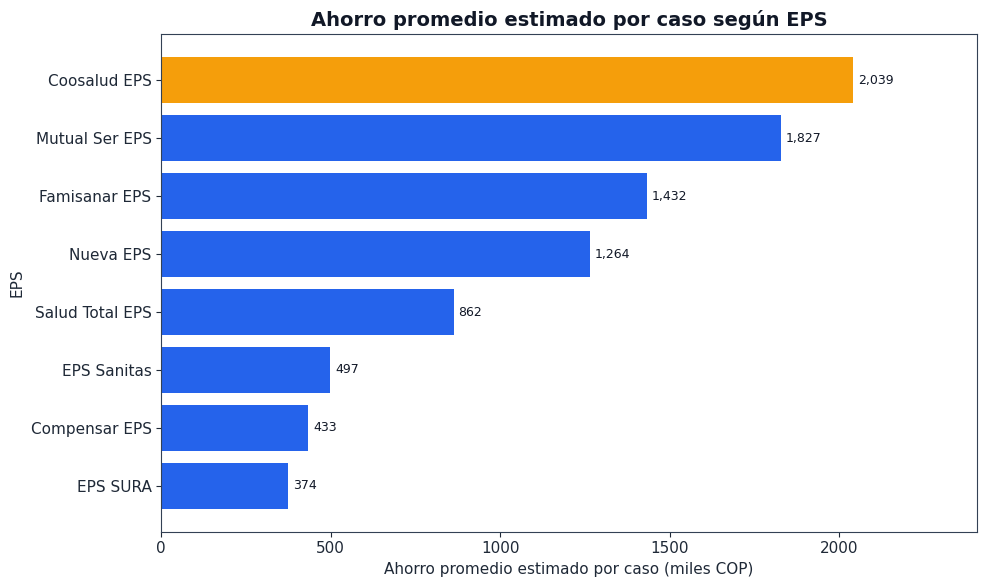

In [102]:

# 1. Ahorro promedio estimado por EPS
# Se resalta la EPS con mayor ahorro promedio por caso.

df_plot = resumen_eps.sort_values("ahorro_promedio_estimado_cop", ascending=True).copy()
df_plot["ahorro_promedio_miles"] = miles_cop(df_plot["ahorro_promedio_estimado_cop"])

mejor_eps = df_plot.loc[df_plot["ahorro_promedio_estimado_cop"].idxmax(), "eps"]
colores = ["#f59e0b" if eps == mejor_eps else "#2563eb" for eps in df_plot["eps"]]

plt.figure(figsize=(10, 6))
plt.barh(df_plot["eps"], df_plot["ahorro_promedio_miles"], color=colores)
plt.xlabel("Ahorro promedio estimado por caso (miles COP)")
plt.ylabel("EPS")
plt.title("Ahorro promedio estimado por caso según EPS")

for i, valor in enumerate(df_plot["ahorro_promedio_miles"]):
    plt.text(valor + 15, i, f"{valor:,.0f}", va="center", fontsize=9)

plt.xlim(0, df_plot["ahorro_promedio_miles"].max() * 1.18)
guardar_figura("01_ahorro_promedio_por_eps.png")


Figura guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/negocio_eps_ips/02_reduccion_promedio_dias_por_eps.png


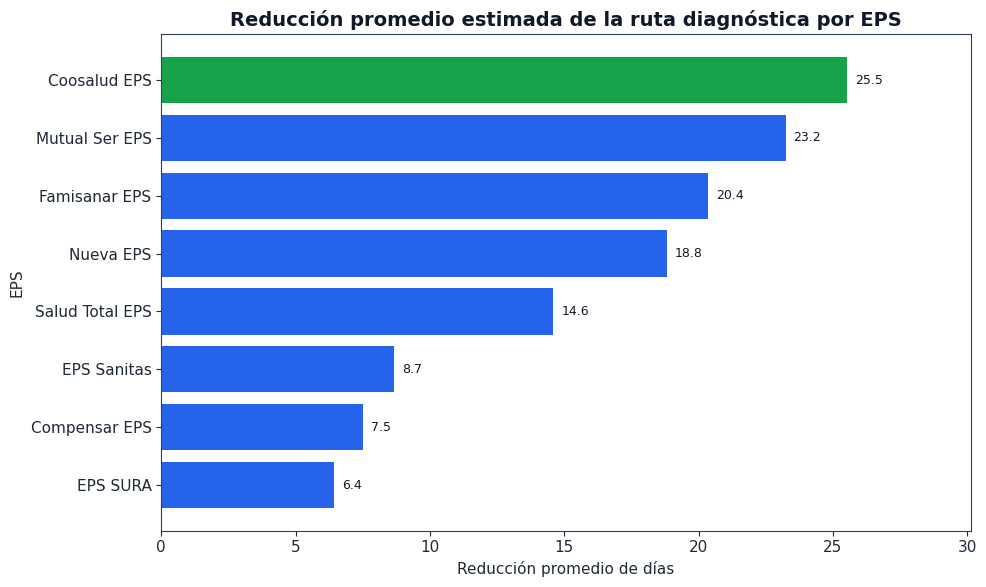

In [103]:

# 2. Reducción promedio de días por EPS
# Se resalta la EPS con mayor reducción estimada de la ruta diagnóstica.

df_plot = resumen_eps.sort_values("reduccion_promedio_dias", ascending=True).copy()

mejor_eps = df_plot.loc[df_plot["reduccion_promedio_dias"].idxmax(), "eps"]
colores = ["#16a34a" if eps == mejor_eps else "#2563eb" for eps in df_plot["eps"]]

plt.figure(figsize=(10, 6))
plt.barh(df_plot["eps"], df_plot["reduccion_promedio_dias"], color=colores)
plt.xlabel("Reducción promedio de días")
plt.ylabel("EPS")
plt.title("Reducción promedio estimada de la ruta diagnóstica por EPS")

for i, valor in enumerate(df_plot["reduccion_promedio_dias"]):
    plt.text(valor + 0.3, i, f"{valor:.1f}", va="center", fontsize=9)

plt.xlim(0, df_plot["reduccion_promedio_dias"].max() * 1.18)
guardar_figura("02_reduccion_promedio_dias_por_eps.png")


Figura guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/negocio_eps_ips/03_comparacion_costos_promedio_por_eps.png


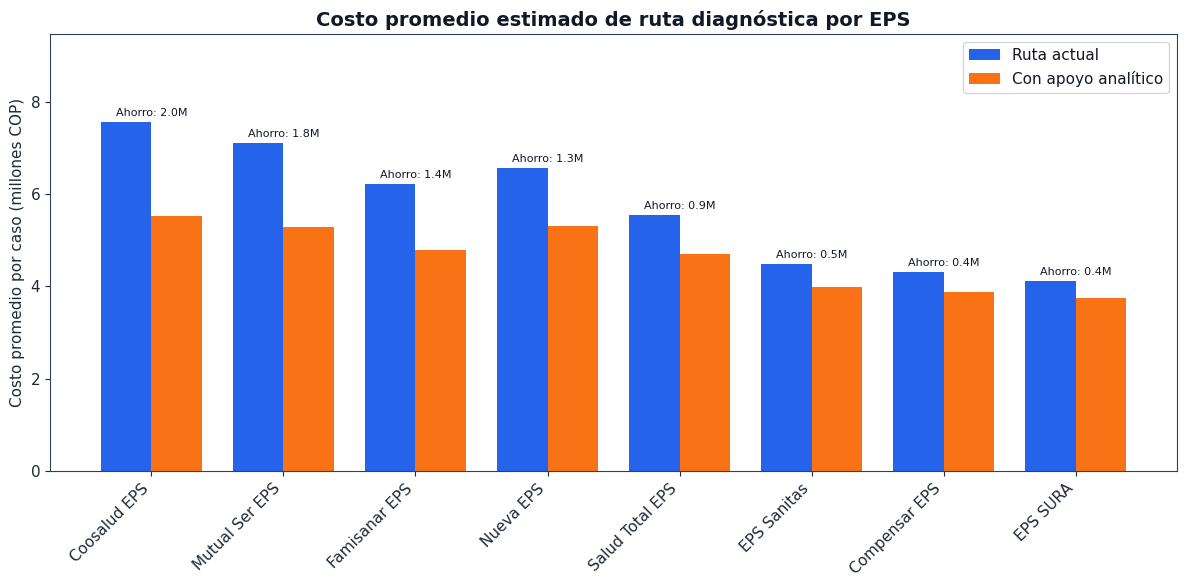

In [104]:

# 3. Comparación de costo promedio: ruta actual vs ruta con analítica
# Se ordena por ahorro promedio para que la brecha entre rutas sea más visible.

df_costos = resumen_eps.sort_values("ahorro_promedio_estimado_cop", ascending=False).copy()
x = np.arange(len(df_costos))
width = 0.38

costo_actual_m = millones_cop(df_costos["costo_promedio_actual_cop"])
costo_analitica_m = millones_cop(df_costos["costo_promedio_con_analitica_cop"])
ahorro_m = costo_actual_m - costo_analitica_m

plt.figure(figsize=(12, 6))
plt.bar(
    x - width / 2,
    costo_actual_m,
    width,
    label="Ruta actual",
    color="#2563eb",
)
plt.bar(
    x + width / 2,
    costo_analitica_m,
    width,
    label="Con apoyo analítico",
    color="#f97316",
)

for i, ahorro in enumerate(ahorro_m):
    y = max(costo_actual_m.iloc[i], costo_analitica_m.iloc[i]) + 0.12
    plt.text(i, y, f"Ahorro: {ahorro:.1f}M", ha="center", fontsize=8)

plt.xticks(x, df_costos["eps"], rotation=45, ha="right")
plt.ylabel("Costo promedio por caso (millones COP)")
plt.title("Costo promedio estimado de ruta diagnóstica por EPS")
plt.legend()
plt.ylim(0, costo_actual_m.max() * 1.25)
guardar_figura("03_comparacion_costos_promedio_por_eps.png")


Figura guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/negocio_eps_ips/04_muestras_por_tipo_cancer.png


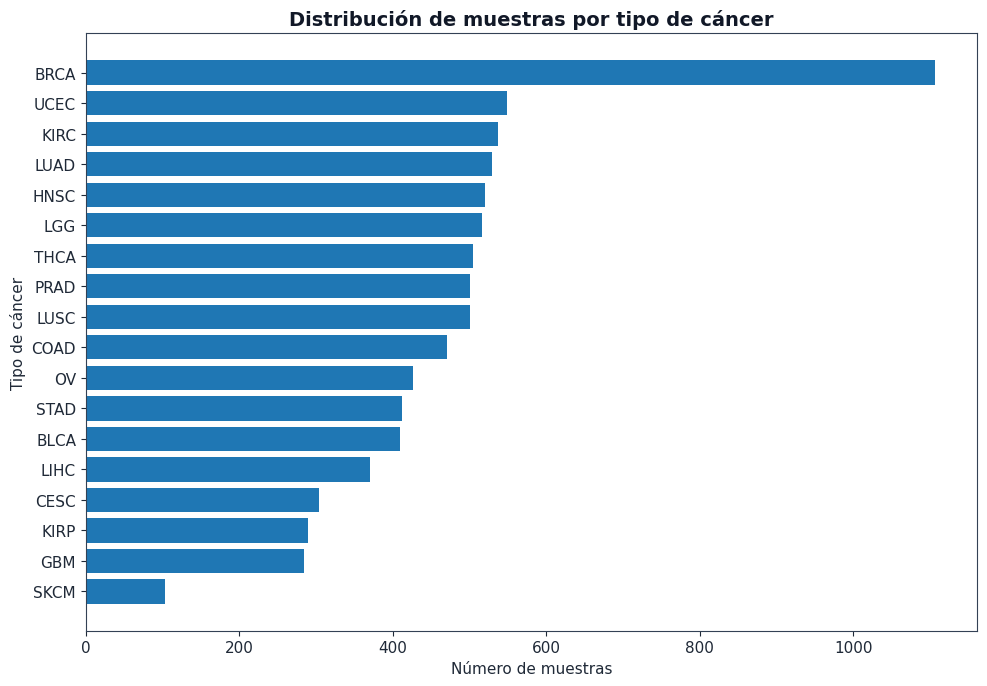

In [105]:
# 4. Distribución de muestras por tipo de cáncer

df_plot = resumen_cancer.sort_values("muestras", ascending=True).copy()

plt.figure(figsize=(10, 7))
plt.barh(df_plot["cancer_type"], df_plot["muestras"])
plt.xlabel("Número de muestras")
plt.ylabel("Tipo de cáncer")
plt.title("Distribución de muestras por tipo de cáncer")
guardar_figura("04_muestras_por_tipo_cancer.png")

Figura guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/negocio_eps_ips/05_ahorro_promedio_por_tipo_cancer.png


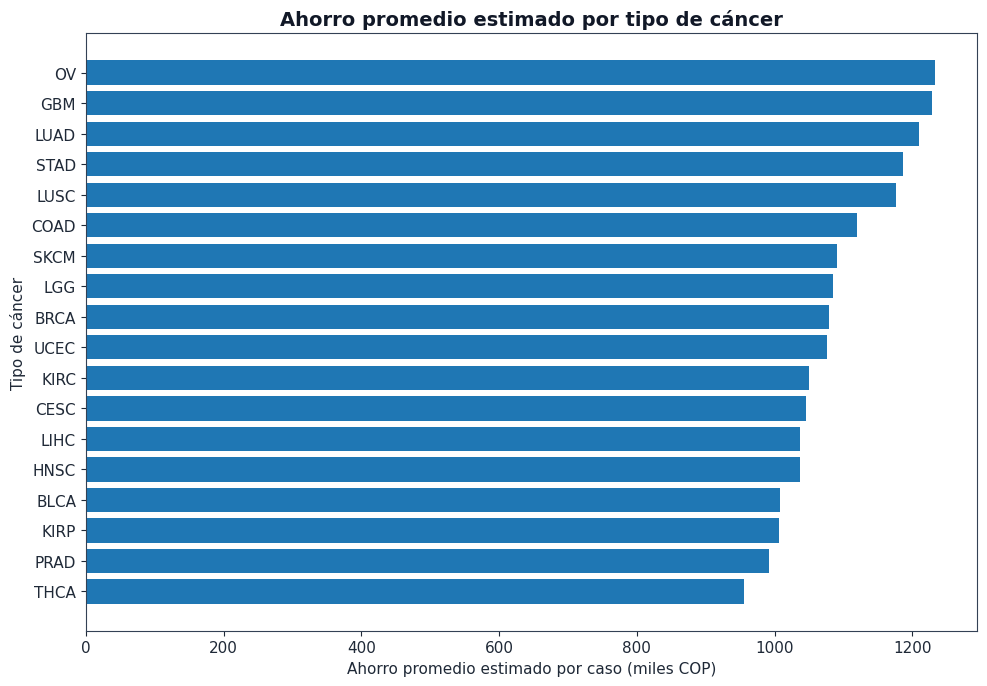

In [106]:
# 5. Ahorro promedio estimado por tipo de cáncer

df_plot = resumen_cancer.sort_values("ahorro_promedio_estimado_cop", ascending=True).copy()
df_plot["ahorro_promedio_miles"] = miles_cop(df_plot["ahorro_promedio_estimado_cop"])

plt.figure(figsize=(10, 7))
plt.barh(df_plot["cancer_type"], df_plot["ahorro_promedio_miles"])
plt.xlabel("Ahorro promedio estimado por caso (miles COP)")
plt.ylabel("Tipo de cáncer")
plt.title("Ahorro promedio estimado por tipo de cáncer")
guardar_figura("05_ahorro_promedio_por_tipo_cancer.png")

Figura guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/negocio_eps_ips/06_mapa_eps_tipo_cancer.png


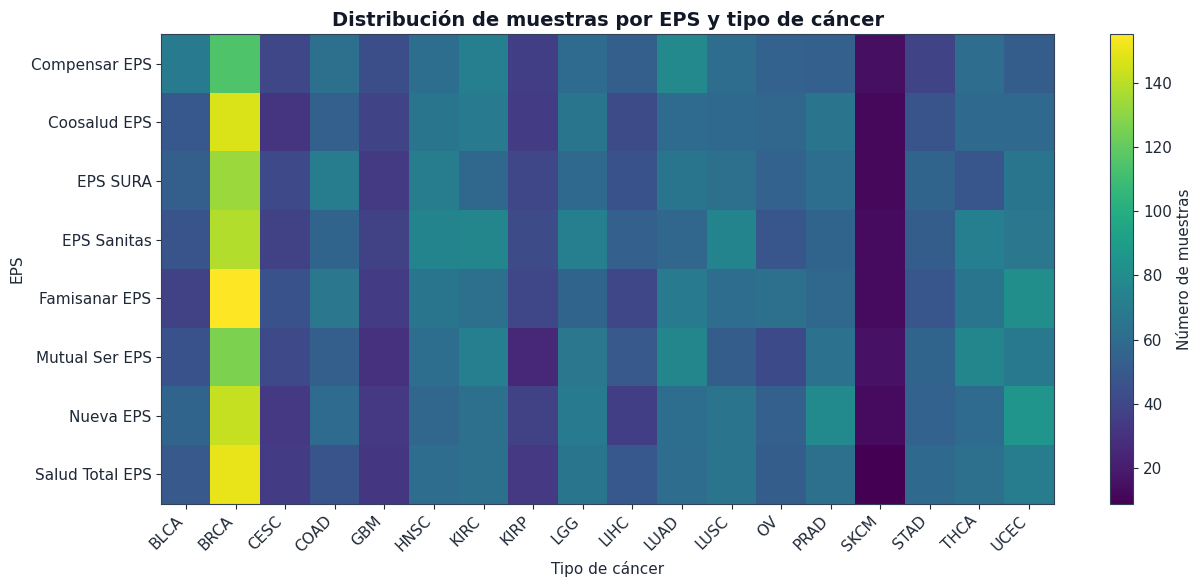

In [107]:
# 6. Mapa de distribución EPS vs tipo de cáncer

tabla_eps_cancer = pd.crosstab(pdf_negocio["eps"], pdf_negocio["cancer_type"])

plt.figure(figsize=(13, 6))
plt.imshow(tabla_eps_cancer, aspect="auto")
plt.colorbar(label="Número de muestras")
plt.xticks(
    ticks=np.arange(len(tabla_eps_cancer.columns)),
    labels=tabla_eps_cancer.columns,
    rotation=45,
    ha="right",
)
plt.yticks(
    ticks=np.arange(len(tabla_eps_cancer.index)),
    labels=tabla_eps_cancer.index,
)
plt.xlabel("Tipo de cáncer")
plt.ylabel("EPS")
plt.title("Distribución de muestras por EPS y tipo de cáncer")
guardar_figura("06_mapa_eps_tipo_cancer.png")

## 12. Validación final de salidas

Se listan las tablas y visualizaciones generadas para verificar que el componente de negocio quedó completo y reproducible.

In [108]:
tablas_generadas = [
    CONTEXTO_NEGOCIO_PATH,
    RESUMEN_EJECUTIVO_PATH,
    RESUMEN_EPS_PATH,
    RESUMEN_CANCER_PATH,
]

print("Tablas refined generadas:")
for ruta in tablas_generadas:
    print("-", ruta.name, "->", ruta.exists())
    if ruta.exists():
        print("  archivos:", [p.name for p in sorted(ruta.iterdir())])

print("\nVisualizaciones generadas:")
for ruta in sorted(VIZ_PATH.glob("*.png")):
    print("-", ruta.name)

print("\nExports para app:")
for ruta in sorted(APP_EXPORTS_PATH.glob("*.csv")):
    print("-", ruta.name)

Tablas refined generadas:
- refined_contexto_negocio_eps_ips_cohorte -> True
  archivos: ['data.csv', 'data.parquet']
- refined_resumen_ejecutivo_eps_ips_cohorte -> True
  archivos: ['data.csv', 'data.parquet']
- refined_resumen_por_eps_cohorte -> True
  archivos: ['data.csv', 'data.parquet']
- refined_resumen_por_tipo_cancer_cohorte -> True
  archivos: ['data.csv', 'data.parquet']

Visualizaciones generadas:
- 01_ahorro_promedio_por_eps.png
- 02_reduccion_promedio_dias_por_eps.png
- 03_comparacion_costos_promedio_por_eps.png
- 04_muestras_por_tipo_cancer.png
- 05_ahorro_promedio_por_tipo_cancer.png
- 06_mapa_eps_tipo_cancer.png
- ahorro_promedio_por_eps.png
- ahorro_promedio_por_tipo_cancer.png
- ahorro_total_por_eps.png
- ahorro_total_por_tipo_cancer.png
- comparacion_costos_por_eps.png
- comparacion_costos_promedio_por_eps.png
- mapa_eps_tipo_cancer.png
- muestras_por_tipo_cancer.png
- reduccion_dias_por_eps.png
- reduccion_promedio_dias_por_eps.png

Exports para app:
- contexto_neg

## 13. Cierre del componente de negocio

Con este notebook se genera una capa analítica orientada a negocio que conecta el modelo de clasificación de cáncer con una lectura operativa para EPS e IPS. Las salidas permiten comunicar tres ideas principales:

1. La matriz molecular puede transformarse en una herramienta de apoyo para priorizar rutas diagnósticas.
2. La analítica puede estimar escenarios de reducción de tiempos y costos asociados a reprocesos diagnósticos.
3. Las tablas y visualizaciones generadas quedan disponibles para dashboards, prototipos de consulta y reporte final.